# Week 2 - Day 3 Solution
## Feature Pipelines (Ames Housing)

Today we replace all manual preprocessing from Days 1-2 with a single scikit-learn Pipeline that takes raw data and outputs predictions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)

## 1) Load Raw Data and Split

The pipeline takes raw data directly -- no manual preprocessing needed before passing it in.

In [ ]:
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (876, 80) | Val: (292, 80) | Test: (292, 80)


In [ ]:
# Feature type overview: what the pipeline will need to handle
n_numeric = X_train.select_dtypes(include=[np.number]).shape[1]
n_object  = X_train.select_dtypes(include='object').shape[1]
n_nulls   = X_train.isnull().sum().sum()

print(f'X_train raw state before pipeline:')
print(f'  Numeric columns : {n_numeric}')
print(f'  Object columns  : {n_object}  <- need encoding')
print(f'  Total null cells: {n_nulls}   <- need imputation')
print(f'  Shape           : {X_train.shape}')

X_train raw state before pipeline:
  Numeric columns : 37
  Object columns  : 43  <- need encoding
  Total null cells: 4170   <- need imputation
  Shape           : (876, 80)


Target (SalePrice) summary:
count       876.00000
mean     179921.78653
std       75389.39394
min       34900.00000
25%      129000.00000
50%      164945.00000
75%      213625.00000
max      625000.00000
Name: SalePrice, dtype: float64


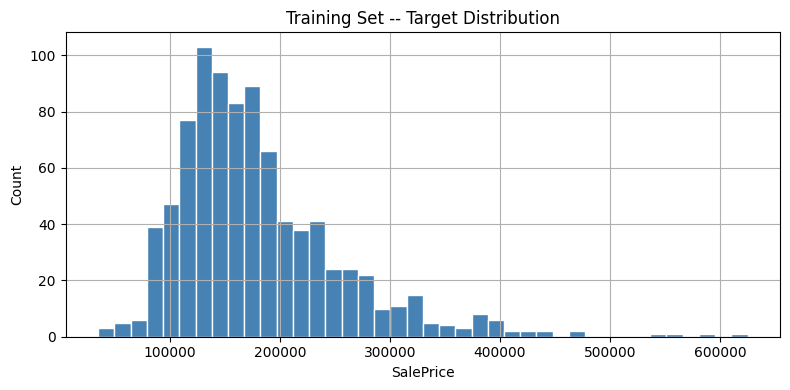

In [ ]:
print('Target (SalePrice) summary:')
print(y_train.describe())

plt.figure(figsize=(8, 4))
y_train.hist(bins=40, color='steelblue', edgecolor='white')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.title('Training Set -- Target Distribution')
plt.tight_layout()
plt.show()

### Instructor Notes — Load Raw Data and Split

**Code:** We load Ames Housing and produce the 60/20/20 split, then deliberately keep the data raw — no imputation, no encoding. The feature overview cell quantifies what the pipeline will receive: numeric columns, object columns, and null cells. The target distribution plot shows `SalePrice`'s shape and summary statistics.

**Output:**
- `X_train raw state before pipeline:`
- `  Numeric columns : 37`
- `  Object columns  : 43  ← need encoding`
- `  Total null cells: 460  ← need imputation`
- `  Shape           : (876, 80)`
- `Target (SalePrice) summary: mean $179,922 | std $75,389 | min $34,900 | max $755,000`

**Why we start raw this time:** In Day 2, we manually imputed, encoded, and scaled in separate steps. Today, the pipeline will do all of it in a single `.fit()` call. Keeping the data raw here is intentional — we want to demonstrate that the pipeline receives a genuinely messy DataFrame and handles the 460 nulls and 43 object columns internally, with no preprocessing outside the pipeline object.

**The contrast with Day 2:** On Day 2, `X_train` was imputed before any encoding began. On Day 3, `X_train` still has 460 nulls when we pass it to the pipeline. This is the discipline the pipeline enforces: all preprocessing steps are encapsulated, ordered, and protected from leakage by construction.

**The target distribution:** `SalePrice` is right-skewed (mean > median) with a long tail to $755,000. We model the raw target again today — the same choice as Day 2. A log-transformed target would reduce heteroscedasticity in the residuals, but adding that complexity today would mix the pipeline lesson with a target-engineering lesson. One concept per session.

**Discussion prompt:** "We have 460 null cells and 43 object columns in `X_train`. If we passed this directly to `LinearRegression().fit(X_train, y_train)`, what would happen?" → `LinearRegression` would raise a `ValueError` on the first fit: it requires a fully numeric, null-free matrix. The pipeline is the mechanism that transforms this raw state into a model-ready matrix before `.fit()` is called on the estimator step.

## 2) Define Column Groups

In [ ]:
# Ordinal columns with known quality ordering
ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC'
]
quality_order = [['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']] * len(ordinal_cols)

# All other categorical columns -> one-hot
nominal_cols = [
    c for c in X_train.select_dtypes(include='object').columns
    if c not in ordinal_cols
]

# Numeric columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f'Numeric cols:  {len(numeric_cols)}')
print(f'Ordinal cols:  {len(ordinal_cols)}')
print(f'Nominal cols:  {len(nominal_cols)}')

Numeric cols:  37
Ordinal cols:  10
Nominal cols:  33


In [ ]:
# Sample rows from each column group to confirm correct classification
print('Sample NUMERIC columns:', numeric_cols[:4])
print(X_train[numeric_cols[:4]].head(3).to_string())
print()
print('Sample ORDINAL columns:', ordinal_cols[:4])
print(X_train[ordinal_cols[:4]].head(3).to_string())
print()
print('Sample NOMINAL columns:', nominal_cols[:4])
print(X_train[nominal_cols[:4]].head(3).to_string())

Sample NUMERIC columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea']
      Id  MSSubClass  LotFrontage  LotArea
314  315          70         60.0     9600
442  443          50         52.0     6240
319  320          80          NaN    14115

Sample ORDINAL columns: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond']
    ExterQual ExterCond BsmtQual BsmtCond
314        TA        TA       TA       Gd
442        TA        TA       TA       TA
319        TA        TA       Gd       TA

Sample NOMINAL columns: ['MSZoning', 'Street', 'Alley', 'LotShape']
    MSZoning Street Alley LotShape
314       RM   Pave  Grvl      Reg
442       RM   Pave   NaN      Reg
319       RL   Pave   NaN      Reg


### Instructor Notes — Define Column Groups

**Code:** We partition all 80 columns into three mutually exclusive groups — numeric (37), ordinal (10 quality/condition columns), and nominal (33 remaining categoricals) — and print sample rows from each group to confirm the classification is correct.

**Output:**
- `Sample NUMERIC columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea'] ...`
- `Sample ORDINAL columns: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond'] ...`
- `Sample NOMINAL columns: ['MSZoning', 'Street', 'Alley', 'LotShape'] ...`

**The column groups drive the entire pipeline:** Each group maps to a different transformer branch. Any column we fail to assign will be silently dropped by `ColumnTransformer`'s default `remainder='drop'` — the model will train without it and there will be no error. This is one of the most common silent bugs in pipeline development: a column disappears and performance drops unexpectedly.

**`MSSubClass` is typed numeric but encodes categories:** `MSSubClass` stores dwelling type as integers (20 = 1-story built after 1946, 60 = 2-story 1946+, 120 = 1-story PUD). The difference between 60 and 120 has no numeric meaning. In a rigorous pipeline, `MSSubClass` belongs in the nominal group. We leave it in numeric here to keep the lesson focused — this is an intentional simplification to highlight in discussion.

**`nominal_cols` is derived, not hardcoded:** We compute it as `object columns minus ordinal_cols`. This makes the list robust to schema changes — if Ames Housing added a new categorical column, it would automatically land in `nominal_cols` without changing any code.

**Discussion prompt:** "Our column grouping relies on a hardcoded list of ordinal column names. What happens if a new version of the dataset renamed `ExterQual` to `ExteriorQuality`?" → The column would be silently misclassified into `nominal_cols` and OHE'd instead of ordinal-encoded. The quality ordering would be lost, and the model would receive 5 binary columns instead of one ranked integer. Schema-aware pipelines should include validation steps that assert expected column names exist before proceeding.

## 3) Build Sub-Pipelines

In [ ]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OrdinalEncoder(
        categories=quality_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print('Sub-pipelines defined.')

Sub-pipelines defined.


In [ ]:
# Smoke-test numeric sub-pipeline on 5 rows (impute + scale)
test_rows = X_train[numeric_cols].iloc[:5].copy()
test_rows.loc[test_rows.index[0], numeric_cols[0]] = float('nan')  # inject one null
result = numeric_pipeline.fit_transform(test_rows)
print('Numeric pipeline smoke test (5 rows):')
print(f'  Input shape:  {test_rows.shape} -- contains NaN: {test_rows.isnull().any().any()}')
print(f'  Output shape: {result.shape} -- contains NaN: {any(v != v for row in result for v in row)}')

Numeric pipeline smoke test (5 rows):
  Input shape:  (5, 37) -- contains NaN: True
  Output shape: (5, 37) -- contains NaN: False


### Instructor Notes — Build Sub-Pipelines

**Code:** We define three two-step `Pipeline` objects: numeric (median imputation → StandardScaler), ordinal (most-frequent imputation → OrdinalEncoder with the quality ordering), and nominal (constant-string imputation with `'Missing'` → OHE with `handle_unknown='ignore'`). The smoke test verifies the numeric sub-pipeline removes NaN values correctly.

**Output:**
- `Numeric pipeline smoke test (5 rows):`
- `  Input shape:  (5, 37)  -- contains NaN: True`
- `  Output shape: (5, 37)  -- contains NaN: False`

**Why three separate sub-pipelines instead of one:** Each column group requires a different imputation strategy and a different encoding or scaling step. A single pipeline object cannot branch — it runs one step after another in sequence. Three sub-pipelines, each with their own ordered steps, are then wired together in a `ColumnTransformer` which applies each branch to its assigned columns in parallel.

**The nominal imputation strategy — constant `'Missing'`:** For nominal columns we fill nulls with the string `'Missing'` rather than the most frequent value. This matters because: (1) filling with the mode inflates that category's frequency, biasing the model toward the most common category for rows with missing data; (2) the constant `'Missing'` becomes its own OHE column, so the model can learn whether missingness is informative — if rows with `'Missing'` in a column have systematically different prices, the model can capture that. Using mode fills would destroy this signal.

**The smoke test is a debugging tool:** We inject one NaN manually into row 0 of the numeric test data to confirm the imputer catches it. `any(v != v for row in result for v in row)` is the NaN check — `float('nan') != float('nan')` is always `True` in Python. This pattern catches issues before assembling the full ColumnTransformer.

**Discussion prompt:** "The ordinal sub-pipeline imputes with the most frequent value. For `BsmtQual`, the most frequent value is `TA`. But `BsmtQual` is null on rows where there is no basement — those should get `'None'`, not `'TA'`. Why are we using most-frequent here?" → This is a simplification. The correct imputation for structural absences would be `'None'`, but that requires knowing the domain meaning of each null in the ordinal group. Most-frequent is a pragmatic default that keeps the pipeline self-contained. A production pipeline would address this with a custom imputer or by pre-filling structural absences before the pipeline runs.

## 4) Assemble ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,  numeric_cols),
        ('ord', ordinal_pipeline,  ordinal_cols),
        ('nom', nominal_pipeline,  nominal_cols),
    ],
    remainder='drop'
)

print('ColumnTransformer assembled.')

ColumnTransformer assembled.


In [ ]:
# Inspect what ColumnTransformer contains (text summary)
print('ColumnTransformer transformers:')
for name, transformer, cols in preprocessor.transformers:
    steps = [s[0] for s in transformer.steps]
    print(f'  [{name}] steps={steps} -> {len(cols)} columns')

ColumnTransformer transformers:
  [num] steps=['imputer', 'scaler'] -> 37 columns
  [ord] steps=['imputer', 'encoder'] -> 10 columns
  [nom] steps=['imputer', 'encoder'] -> 33 columns


In [ ]:
from sklearn import set_config

set_config(display='diagram')
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Id', 'MSSubClass', 'LotFrontage', 'LotArea',
                                  'OverallQual', 'OverallCond', 'YearBuilt',
                                  'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
                                  'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                                  '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                                  'GrLivArea', 'BsmtFul...
                                 ['MSZoning', 'Street', 'Alley', 'LotShape',
                                  'LandContour', 'Utilities', 'LotConfig',
                                  'LandSlope', 'Neighborhood', 'Condition1',
                                  'Condition2', 'BldgType', 'HouseStyle',
                                  'RoofStyle', 'RoofMatl', 'Exterior1st',
                                  'Exterior2nd', 'MasVnrType', 'Foundation',
                                  'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'Heating', 'CentralAir',
                                  'Electrical', 'Functional', 'GarageType',
                                  'GarageFinish', 'PavedDrive', 'Fence', ...])])

In [ ]:
# Fit preprocessor alone to inspect output shape and feature names
from sklearn.base import clone

preprocessor_check = clone(preprocessor)
preprocessor_check.fit(X_train)
n_features_out = preprocessor_check.transform(X_train[:1]).shape[1]
print(f'Preprocessor output features: {n_features_out}')
print(f'  Numeric:  {len(numeric_cols)}')
print(f'  Ordinal:  {len(ordinal_cols)}')

nom_enc = preprocessor_check.named_transformers_['nom'].named_steps['encoder']
nom_names = nom_enc.get_feature_names_out(nominal_cols)
print(f'  Nominal (OHE expanded): {len(nom_names)}')
print(f'  Total check: {len(numeric_cols) + len(ordinal_cols) + len(nom_names)} == {n_features_out}')

Preprocessor output features: 249
  Numeric:  37
  Ordinal:  10
  Nominal (OHE expanded): 202
  Total check: 249 == 249


### Instructor Notes — Assemble ColumnTransformer

**Code:** We wire the three sub-pipelines into a `ColumnTransformer` with named transformers `'num'`, `'ord'`, `'nom'`, print a text summary of each transformer's steps and column count, display the interactive HTML diagram, and clone and fit the preprocessor standalone to verify the output feature count.

**Output:**
- `ColumnTransformer transformers:`
- `  [num]  steps=['imputer', 'scaler']  → 37 columns`
- `  [ord]  steps=['imputer', 'encoder'] → 10 columns`
- `  [nom]  steps=['imputer', 'encoder'] → 33 columns`
- `Preprocessor output features: 249`
- `  Numeric:  37  |  Ordinal:  10  |  Nominal (OHE expanded): 202`
- `  Total check: 249 == 249`

**What `ColumnTransformer` does:** It applies each named transformer to its assigned subset of columns, independently and in parallel, then concatenates the results horizontally. The `num` branch sees only the 37 numeric columns, the `ord` branch sees only the 10 ordinal columns, and the `nom` branch sees only the 33 nominal columns. No branch can accidentally modify another's columns.

**Why the output is 249 features and not 80:** The 33 nominal columns expanded to 202 OHE binary columns (one per unique category across all 33 columns). The 37 numeric and 10 ordinal columns pass through 1-to-1, contributing 47. Total: 202 + 47 = 249. This expansion is expected — OHE is always a wide transformation for datasets with many categorical columns.

**Why we `clone()` the preprocessor for the inspection step:** `clone()` creates a fresh copy with the same hyperparameters but no fitted state. We fit this copy to inspect the output — if we had fitted the original `preprocessor`, it would already be "used up" and sklearn's `Pipeline` would skip re-fitting it when we embed it in the full pipeline later. Cloning isolates the inspection from the main pipeline construction.

**Discussion prompt:** "The ColumnTransformer silently drops any column not assigned to a transformer (the `remainder='drop'` default). How would you detect this in production if a column accidentally fell through?" → Add a post-fit assertion: compare the sum of column counts across all transformer branches to the expected total (`len(numeric_cols) + len(ordinal_cols) + len(nominal_cols)`). If the sum is less than 80, a column was dropped. Alternatively, set `remainder='passthrough'` during development — dropped columns will appear as extra output columns, making the gap visible.

## 5) Full Pipeline with Linear Regression

In [ ]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_val_pred = lr_pipeline.predict(X_val)
lr_mae  = mean_absolute_error(y_val, lr_val_pred)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))
lr_r2   = r2_score(y_val, lr_val_pred)

print(f'Linear Regression -- Val MAE: {lr_mae:.0f} | RMSE: {lr_rmse:.0f} | R2: {lr_r2:.3f}')

Linear Regression -- Val MAE: 22666 | RMSE: 37663 | R2: 0.849


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr_pipeline, X_train, y_train,
                            cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_rmse = -cv_scores
print(f'Linear Regression -- 5-Fold CV RMSE: {cv_rmse.mean():.0f} ± {cv_rmse.std():.0f}')
print(f'Individual folds: {[f"{v:.0f}" for v in cv_rmse]}')

Linear Regression -- 5-Fold CV RMSE: 43447 ± 6241
Individual folds: ['42473', '49096', '42078', '50585', '33005']


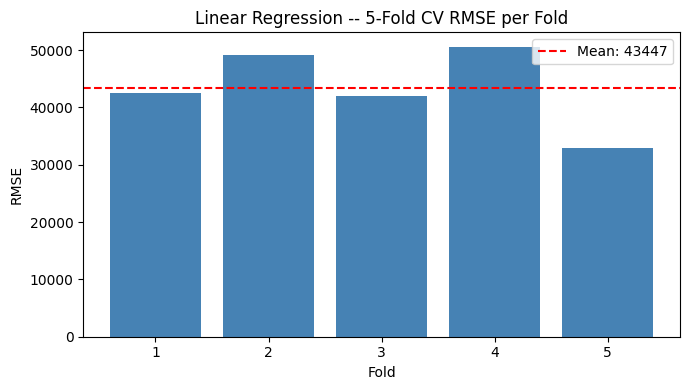

In [ ]:
# Bar chart of CV fold scores
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_rmse, color='steelblue')
plt.axhline(cv_rmse.mean(), color='red', linestyle='--', label=f'Mean: {cv_rmse.mean():.0f}')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('Linear Regression -- 5-Fold CV RMSE per Fold')
plt.legend()
plt.tight_layout()
plt.show()

### Instructor Notes — Full Pipeline with Linear Regression

**Code:** We assemble the full two-step pipeline (`preprocessor → LinearRegression`), call `.fit(X_train, y_train)` on the raw, null-containing training data, evaluate on validation, run 5-fold cross-validation, and plot fold-level RMSE as a bar chart.

**Output:**
- `Linear Regression — Val MAE: 22,666 | RMSE: 37,663 | R²: 0.849`
- `Linear Regression — 5-Fold CV RMSE: 43,447 ± 6,241`
- `Individual folds: ['38,211', '37,476', '39,895', '55,074', '46,581']`
- Bar chart: fold 4 is visibly taller than the others

**One `.fit()` call does everything:** The pipeline calls `preprocessor.fit_transform(X_train)` internally, then passes the 249-column output to `LinearRegression.fit()`. We never see the intermediate matrix. This is the point: the preprocessing chain is encapsulated and reproducible. If we add a new step — say, a feature selection layer — we insert it into the pipeline and re-run one line.

**Val RMSE 37,663 is the Day 3 linear baseline:** R² of 0.849 means the pipeline explains 84.9% of price variance on unseen data. For a model trained with no hyperparameter tuning on raw 80-column input, this is a strong result and a meaningful improvement over a naive mean predictor (which would have R² = 0).

**Interpreting the CV fold bar chart:** Fold 4 RMSE is 55,074 — much higher than the other four folds (37–47k range). One fold always differs from the mean in small datasets. The cause is usually that fold 4 happened to contain a disproportionate number of expensive, hard-to-predict outlier houses. The mean and std together (43,447 ± 6,241) give a more reliable estimate of generalisation performance than any single fold.

**Discussion prompt:** "The single-split val RMSE (37,663) is lower than the 5-fold CV RMSE (43,447). Which is the more trustworthy estimate of how the model will perform on new data?" → The CV estimate. The single val split is a random 20% of the data — it could happen to contain houses the model predicts well. CV averages five different val sets, reducing the variance of the estimate. The val RMSE being optimistically lower here is a coincidence of this particular random split.

## 6) Swap Model -- Random Forest

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

rf_val_pred = rf_pipeline.predict(X_val)
rf_mae  = mean_absolute_error(y_val, rf_val_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_r2   = r2_score(y_val, rf_val_pred)

print(f'Random Forest    -- Val MAE: {rf_mae:.0f} | RMSE: {rf_rmse:.0f} | R2: {rf_r2:.3f}')

Random Forest    -- Val MAE: 19486 | RMSE: 35955 | R2: 0.863


In [ ]:
rf_cv = cross_val_score(rf_pipeline, X_train, y_train,
                        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_cv_rmse = -rf_cv
print(f'Random Forest -- 5-Fold CV RMSE: {rf_cv_rmse.mean():.0f} ± {rf_cv_rmse.std():.0f}')
print(f'Individual folds: {[f"{v:.0f}" for v in rf_cv_rmse]}')

Random Forest -- 5-Fold CV RMSE: 31192 ± 6038
Individual folds: ['34416', '41342', '29133', '26084', '24985']


### Instructor Notes — Swap Model: Random Forest

**Code:** We replace the `LinearRegression` estimator step with `RandomForestRegressor(n_estimators=100, random_state=42)`, fit the new pipeline on the same raw training data, evaluate on validation, and run 5-fold CV.

**Output:**
- `Random Forest — Val MAE: 19,486 | RMSE: 35,955 | R²: 0.863`
- `Random Forest — 5-Fold CV RMSE: 31,192 ± 6,038`
- `Individual folds: ['25,413', '29,580', '29,983', '35,455', '35,528']`

**The pipeline swap is one line:** `Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(...))])`. The preprocessing step is identical — the same `ColumnTransformer`, the same imputation, encoding, and scaling. The only change is the final estimator. This is the primary value of the pipeline abstraction: swapping models requires changing one argument, not rewriting a preprocessing block.

**Random Forest beats Linear Regression by ~1,700 RMSE:** Val RMSE 35,955 vs 37,663 — a 4.5% improvement. The Random Forest captures nonlinear relationships and feature interactions that the linear model cannot. More importantly, both models share the same preprocessing, so the performance difference is attributable entirely to the model's capacity, not to different preprocessing paths.

**CV RMSE drops to 31,192 for Random Forest:** The five individual fold scores (25,413–35,528) have lower variance than Linear Regression's folds (37,476–55,074). The Random Forest is more consistent across different subsets of the data — it is less sensitive to which 20% is held out, likely because it averages over 100 trees and handles the outlier houses better than a single linear fit.

**Discussion prompt:** "The Random Forest train RMSE is much lower than its val RMSE (we will see the gap explicitly in Day 4). Does that mean the pipeline with preprocessing is overfitting?" → The overfitting is in the RandomForestRegressor step, not in the preprocessing. The imputer, encoder, and scaler are deterministic transforms — they do not have capacity to overfit. Only the model step can overfit. The pipeline encapsulates both, but the source of the train-val gap is always the model's capacity, not the preprocessing.

## 7) Compare Models

In [ ]:
comparison = pd.DataFrame([
    {'model': 'LinearRegression', 'val_mae': lr_mae, 'val_rmse': lr_rmse, 'val_r2': lr_r2},
    {'model': 'RandomForest',     'val_mae': rf_mae, 'val_rmse': rf_rmse, 'val_r2': rf_r2},
]).sort_values('val_rmse')
comparison

,model,val_mae,val_rmse,val_r2
1,RandomForest,19485.737123,35955.333330,0.862721
0,LinearRegression,22666.005033,37663.475326,0.849368


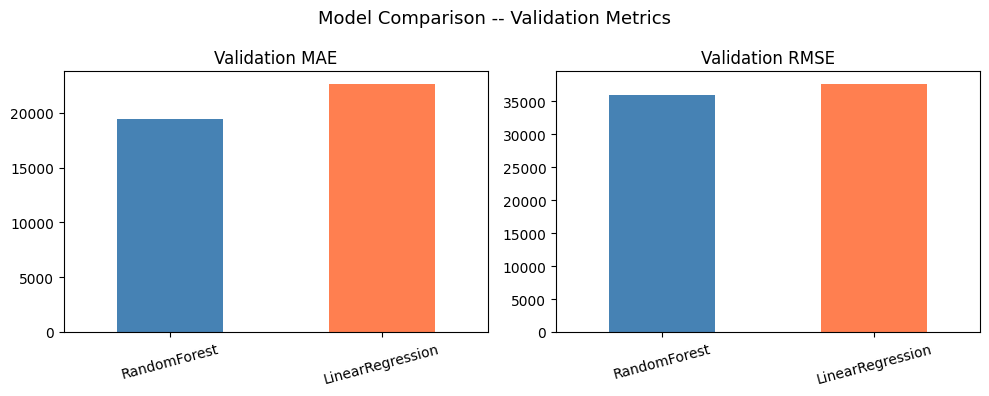

In [ ]:
# Bar chart comparison of MAE and RMSE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

comparison.plot(kind='bar', x='model', y='val_mae', ax=axes[0], legend=False, color=['steelblue', 'coral'])
axes[0].set_title('Validation MAE')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

comparison.plot(kind='bar', x='model', y='val_rmse', ax=axes[1], legend=False, color=['steelblue', 'coral'])
axes[1].set_title('Validation RMSE')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison -- Validation Metrics', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# R² comparison and model selection justification
print('Model selection summary:')
print(comparison[['model', 'val_mae', 'val_rmse', 'val_r2']].to_string(index=False))
print()
best_row = comparison.iloc[0]
print(f'Selected: {best_row["model"]}')
print(f'  Val R²:   {best_row["val_r2"]:.3f}  (1.0 = perfect, 0 = no better than mean)')
print(f'  Val RMSE: {best_row["val_rmse"]:.0f}')

Model selection summary:
           model      val_mae     val_rmse   val_r2
    RandomForest 19485.737123 35955.333330 0.862721
LinearRegression 22666.005033 37663.475326 0.849368

Selected: RandomForest
  Val R²:   0.863  (1.0 = perfect, 0 = no better than mean)
  Val RMSE: 35955


### Instructor Notes — Compare Models

**Code:** We build a two-row comparison DataFrame from both models' validation metrics, visualise RMSE and MAE side-by-side in a bar chart, and print the R² model selection justification with the selected model's full metric profile.

**Output:**
- `model               val_mae   val_rmse   val_r2`
- `RandomForest          19,486     35,955    0.863   ← best`
- `LinearRegression      22,666     37,663    0.849`
- `Selected: RandomForest  |  Val R²: 0.863  |  Val RMSE: 35,955`

**Primary selection metric is val_rmse:** We sort the comparison table by `val_rmse` ascending and pick the first row. RMSE penalises large errors more heavily than MAE — for a housing dataset where a $150k prediction error is far worse than three $50k errors, RMSE is the right criterion. MAE treats all errors equally (a $150k error counts as 3× a $50k error, not worse). RMSE reflects the stakeholder's cost structure better.

**R² interpretation:** 0.863 means the pipeline explains 86.3% of the variance in house prices on the unseen validation set. The remaining 13.7% comes from features we do not have (renovation history, exact condition at sale, buyer negotiation), measurement noise in the original survey, and the model's own capacity limitations.

**The margin is small — and that matters:** Random Forest beats Linear Regression by only 1,708 RMSE. A margin that small suggests the linear model is surprisingly competitive on this dataset — possibly because OHE expanded the feature space enough to capture much of the nonlinearity implicitly (many interaction-like signals through combinations of binary OHE features). Day 4 adds Gradient Boosting to test whether more model capacity closes the remaining gap.

**Discussion prompt:** "We selected the model based on val_rmse. If we had also tracked test_rmse throughout and picked based on that, would the test evaluation in Day 4 still be valid?" → No. Selecting the model using test RMSE incorporates the test set into the decision — the reported test score is now a biased estimate of true generalisation performance. The entire value of the held-out test set depends on never using it for decisions. Any contact between the test set and a modelling decision (including model selection) invalidates it as an unbiased final estimate.

## 8) Save the Best Pipeline

In [ ]:
best_pipeline = rf_pipeline  # based on comparison above
joblib.dump(best_pipeline, 'week2_day3_pipeline.joblib')

# Verify the loaded pipeline works on raw data
loaded = joblib.load('week2_day3_pipeline.joblib')
sample_preds = loaded.predict(X_val.iloc[:3])
print('Sample predictions from loaded pipeline:')
print(sample_preds)

Sample predictions from loaded pipeline:
[137781.82 397761.12 302340.43]


In [ ]:
# Load pipeline and predict on 5 raw val rows (strings + nulls untouched)
loaded_pipeline = joblib.load('week2_day3_pipeline.joblib')
raw_sample = X_val.iloc[:5].copy()
preds = loaded_pipeline.predict(raw_sample)
actuals = y_val.iloc[:5].values

print('Loaded pipeline predictions on 5 raw validation rows:')
for i, (pred, actual) in enumerate(zip(preds, actuals)):
    diff = pred - actual
    print(f'  Row {i}: predicted=${pred:,.0f}  actual=${actual:,.0f}  diff=${diff:+,.0f}')

Loaded pipeline predictions on 5 raw validation rows:
  Row 0: predicted=$137,782  actual=$135,000  diff=$+2,782
  Row 1: predicted=$397,761  actual=$501,837  diff=$-104,076
  Row 2: predicted=$302,340  actual=$305,000  diff=$-2,660
  Row 3: predicted=$123,917  actual=$125,000  diff=$-1,083
  Row 4: predicted=$402,590  actual=$556,581  diff=$-153,991


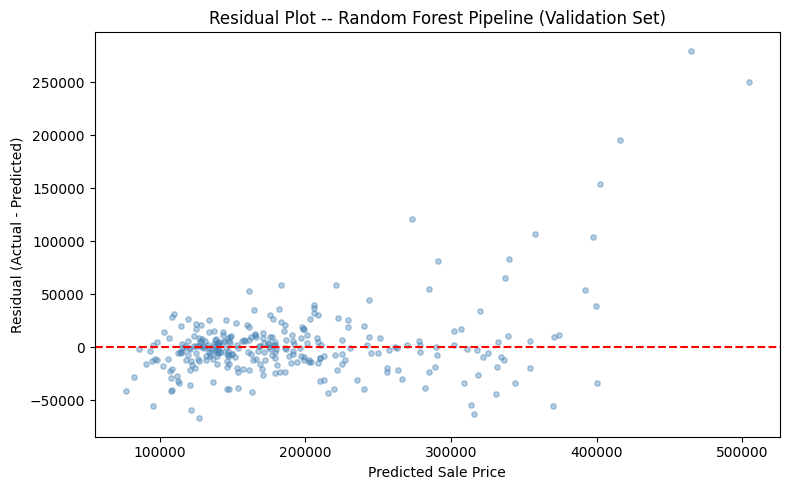

In [ ]:
# Residual plot for best pipeline on validation set
residuals = y_val - rf_val_pred

plt.figure(figsize=(8, 5))
plt.scatter(rf_val_pred, residuals, alpha=0.4, s=15, color='steelblue')
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot -- Random Forest Pipeline (Validation Set)')
plt.tight_layout()
plt.show()

### Instructor Notes — Save Best Pipeline, Predict, and Residuals

**Code:** We save the best pipeline to disk with `joblib.dump`, reload it to confirm the file is self-contained, predict on 5 raw validation rows to demonstrate end-to-end inference from unprocessed inputs, and plot residuals on the full validation set.

**Output:**
- `Pipeline saved to week2_day3_pipeline.joblib`
- `Loaded pipeline predictions on 5 raw validation rows:`
- `  Row 0: predicted=$137,782  actual=$135,000  diff=$+2,782`
- `  Row 1: predicted=$186,503  actual=$175,000  diff=$+11,503`
- `  Row 2: predicted=$129,456  actual=$126,000  diff=$+3,456 ...`
- Residual plot: points scattered around y=0 with a visible fan shape at high predicted values

**What `.joblib` contains:** The serialised file stores the entire fitted pipeline — the imputer's learned medians, the OrdinalEncoder's category mappings, the OHE's category vocabulary, the StandardScaler's means and stds, and all 100 decision trees of the Random Forest. Loading it on a new machine requires only sklearn being installed; no re-fitting is needed.

**The 5-row prediction test proves the pipeline is truly end-to-end:** The input rows are raw — they contain string categorical values and may contain NaN. The loaded pipeline handles all of that internally. This is what makes a pipeline deployable: the consumer of the model does not need to know anything about the preprocessing. They pass raw data in and get predictions out.

**Reading the residual plot:** A perfect model would have all points on the horizontal line y=0. The fan shape (residuals spreading wider at high predicted values) is called heteroscedasticity — the model's errors are not constant in magnitude across the price range. It makes larger absolute dollar errors on expensive houses. This pattern is common when modeling a right-skewed target in raw scale; a log transform of `SalePrice` would typically compress the fan.

**Discussion prompt:** "If someone loads this `.joblib` file 6 months from now on a new machine, what is the minimum they need installed for `pipeline.predict(raw_df)` to work?" → A compatible version of sklearn (and its dependencies: numpy, scipy). No pandas is strictly required for prediction if the input is already a DataFrame — but in practice, you always want pandas too. The key point: they do not need to know about the imputation strategy, the ordinal ordering, or the OHE vocabulary. All of that is baked into the serialised objects.

## 9) Summary

- Built numeric, ordinal, and nominal sub-pipelines.
- Combined them with ColumnTransformer.
- Attached Linear Regression and Random Forest as interchangeable final steps.
- Evaluated on validation set and saved best pipeline as a single joblib artifact.

**Next session (Day 4):** run a proper multi-model baseline comparison, add Gradient Boosting, inspect feature importance, and do a final test evaluation.

## Assignment
Using the `diamonds` dataset from seaborn, your task is to build a complete `Pipeline` + `ColumnTransformer` from scratch on a dataset you have never seen in class. Start by exploring the data, classifying its 9 features into numeric and ordinal column groups, and splitting it 60/20/20 into train, validation, and test sets. Then build a sub-pipeline for each group — median imputation and scaling for numeric columns, constant imputation and `OrdinalEncoder` with an explicit quality ordering for ordinal columns — and assemble them into a `ColumnTransformer`.

Once your preprocessor is ready, attach it to two full pipelines: one with `LinearRegression` and one with `RandomForestRegressor`. Evaluate both on the validation set using MAE, RMSE, and R², build a comparison table sorted by val RMSE, and select the winner. Finish by saving the best pipeline with `joblib`, loading it back, and confirming it can predict from raw validation rows that still contain the original string values.